# Construção do Dataset Central (Fase 2)

Este notebook constrói o dataset central que será usado na Fase 3 para testar a arquitetura multi-target.

A base operacional é o dataset BTS 2023 usado nos notebooks de duração/atraso e emissões. Não é feito um join direto com o dataset Expedia/Kaggle, porque o Expedia contém ofertas comerciais de bilhetes e não os mesmos voos operacionais do BTS.

A integração é feita da seguinte forma:

1. **Custo** - o modelo de custo validado no NB01 é transferido para os voos BTS. Primeiro gera-se uma previsão com o RF original e depois treina-se um LightGBM generalista, usando apenas features comuns e generalizáveis.
2. **Duração/atraso** - são mantidas as previsões do NB02b, isto é, a versão sem a feature com data leakage.
3. **Emissões** - é mantido o CO₂ calculado no NB03 através da fórmula física ICAO.

Nesta primeira versão do dataset central são incluídas apenas features internas e derivadas dos três notebooks de replicação. Features externas, como preço do combustível, câmbio, carbono, conflito ou clima, serão adicionadas apenas numa fase posterior, para comparar a arquitetura base com a arquitetura enriquecida.

Para evitar data leakage, não são exportadas features calculadas diretamente a partir dos targets, como custo por km, CO₂ por km, emissões por passageiro-km ou erro rolling de previsão.

Legenda:
- NB01 - notebook de custo
- NB02 - notebook de duração
- NB03 - notebook de emissões

## 0. Setup e Imports

In [5]:
import numpy as np
import pandas as pd
import joblib
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'LightGBM: {lgb.__version__}')

NumPy: 2.3.4
Pandas: 2.3.3
LightGBM: 4.6.0


## 1. Carregar os dados de input

In [6]:
PATH_NB02     = 'nb02_duration_output.csv'
PATH_NB03     = 'nb03_co2_output.csv'
PATH_RF_MODEL = 'modelo_custo_rf.pkl'      # RF original NB01 (para gerar COST_PRED_RF)
PATH_ENCODERS = 'encoders_custo.pkl'       # encoders do RF original

print('A carregar datasets...')
df_nb02 = pd.read_csv(PATH_NB02, low_memory=False)
df_nb03 = pd.read_csv(PATH_NB03, low_memory=False)

print(f'NB02 (duração): {df_nb02.shape}')
print(f'NB03 (CO2):     {df_nb03.shape}')


A carregar datasets...
NB02 (duração): (195950, 23)
NB03 (CO2):     (195950, 24)


## 2. Merge NB02 + NB03

In [ ]:
COLS_NB03_ONLY = ['CO2_kg', 'CO2_tonnes', 'Season']
cols_to_add = [c for c in COLS_NB03_ONLY if c in df_nb03.columns]

assert len(df_nb02) == len(df_nb03), 'Datasets com tamanhos diferentes!'

# Verificar consistência
for col in ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'Month']:
    if col in df_nb02.columns and col in df_nb03.columns:
        match = (df_nb02[col] == df_nb03[col]).mean()
        print(f'Match {col}: {match:.4%}')

df = df_nb02.copy()
df['FL_DATE']    = pd.to_datetime(df['FL_DATE'], errors='coerce')
df['DayofMonth'] = df['FL_DATE'].dt.day
df['DEP_HOUR']   = (pd.to_numeric(df['CRS_DEP_TIME'], errors='coerce') // 100).astype('Int64')
for col in cols_to_add:
    df[col] = df_nb03[col]

# Fator de eficiência de combustível por companhia
# A fórmula ICAO usa 4.5 kg/km para todos os voos.
# Na realidade, companhias com frotas mais modernas emitem menos CO₂.
# Foram aolicados fatores por companhia baseados na média de idade da frota e eficiência
# Referência: Delta/Alaska renovaram frotas com B737-9 e A220 (mais eficientes);
# Southwest usa B737-800 (média); Spirit/Frontier têm frotas A320neo (mais eficientes).
# Fonte de referência: ICCT "CO2 Emissions from Commercial Aviation" 2023.
AIRLINE_EFFICIENCY = {
    'AS': 0.92,   # Alaska - frota moderna (A321neo, B737-9)
    'B6': 0.95,   # JetBlue - A320/A321
    'WN': 0.96,   # Southwest - B737-800 (grande frota uniforme)
    'NK': 0.94,   # Spirit - A320neo (eficiente)
    'F9': 0.94,   # Frontier - A320neo
    'DL': 1.00,   # Delta - frota mista (referência=1.0)
    'UA': 1.02,   # United - frota mais envelhecida em algumas rotas
    'AA': 1.04,   # American - maior frota, mais heterogénea
    'G4': 1.03,   # Allegiant - B737 mais antigos
    'HA': 0.98,   # Hawaiian - A321
    'MQ': 1.05,   # Envoy (AA regional) - ERJ mais antigos
    'OH': 1.05,   # PSA (AA regional)
    'OO': 1.03,   # SkyWest - frota mista
}

# Aplicar fator: CO2_real = CO2_icao × fator_companhia
df['airline_co2_factor'] = df['AIRLINE_CODE'].map(AIRLINE_EFFICIENCY).fillna(1.0)
df['CO2_kg'] = df['CO2_kg'] * df['airline_co2_factor']
df['CO2_tonnes'] = df['CO2_kg'] / 1000

print('CO2_kg após fator de eficiência por companhia:')
print(df.groupby('AIRLINE_CODE').agg(
    co2_mean=('CO2_kg', 'mean'),
    factor=('airline_co2_factor', 'first')
).round(2).sort_values('factor').to_string())
print()
print(f'CO2 médio antes do fator: {df_nb03["CO2_kg"].mean():.0f} kg')
print(f'CO2 médio após fator:     {df["CO2_kg"].mean():.0f} kg')
print(f'Desvio introduzido: std={df["CO2_kg"].std():.0f} kg (era {df_nb03["CO2_kg"].std():.0f})')

Match AIRLINE_CODE: 100.0000%
Match ORIGIN: 100.0000%
Match DEST: 100.0000%
Match Month: 100.0000%
CO2_kg após fator de eficiência por companhia:
              co2_mean  factor
AIRLINE_CODE                  
AS            32301.05    0.92
F9            22762.57    0.94
NK            22174.84    0.94
B6            27062.74    0.95
WN            17294.18    0.96
HA            60652.12    0.98
DL            22644.65    1.00
9E            11431.17    1.00
YX            12677.97    1.00
UA            30055.31    1.02
OO            13425.01    1.03
G4            21987.31    1.03
AA            25499.97    1.04
MQ            14805.23    1.05
OH            12721.16    1.05

CO2 médio antes do fator: 21662 kg
CO2 médio após fator:     21520 kg
Desvio introduzido: std=13524 kg (era 13632)


## 3. Imputação de Custo - Modelo Generalista

### 3.1 Passo 1: Gerar COST_PRED_RF com o modelo original (16 aeroportos)

Usamos o RF do NB01 para obter previsões de custo - mesmo que imperfeitas para aeroportos fora dos 16 de treino, capturam o sinal de preço aprendido do Expedia.

In [8]:
import airportsdata
import time

rf_model = joblib.load(PATH_RF_MODEL)
encoders = joblib.load(PATH_ENCODERS)

MODEL_AIRPORTS = list(encoders['startingAirport'].classes_)
MODEL_AIRLINES = list(encoders['segmentsAirlineCode'].classes_)
airports_db = airportsdata.load('IATA')

# Mapeamento de aeroportos (igual à versão anterior - só para o passo 1)
model_airport_coords = {}
for ap in MODEL_AIRPORTS:
    info = airports_db.get(ap, {})
    if info:
        model_airport_coords[ap] = (info['lat'], info['lon'])

def nearest_model_airport(iata_code):
    if iata_code in MODEL_AIRPORTS:
        return iata_code
    info = airports_db.get(str(iata_code), {})
    if not info:
        return MODEL_AIRPORTS[0]
    lat1, lon1 = info['lat'], info['lon']
    best, best_dist = None, float('inf')
    for ap, (lat2, lon2) in model_airport_coords.items():
        d = (lat1-lat2)**2 + (lon1-lon2)**2
        if d < best_dist:
            best_dist = d
            best = ap
    return best

AIRLINE_MAP = {
    'WN': 'B6', 'NK': 'B6', 'G4': 'B6', 'HA': 'AS',
    'MQ': 'AA', 'OH': 'AA', 'OO': 'UA', '9E': 'DL', 'YX': 'UA',
}

print('Passo 1: a gerar COST_PRED_RF com modelo original...')
t0 = time.time()

CAT = ['startingAirport', 'destinationAirport', 'segmentsAirlineCode',
       'segmentsCabinCode', 'segmentsEquipmentDescription']
NUM = ['searchMonth', 'searchDay', 'flightMonth', 'flightDay',
       'seatsRemaining', 'totalTravelDistance',
       'segmentsDurationInSeconds',
       'segmentsDepartureTimeEpochSeconds',
       'segmentsArrivalTimeEpochSeconds']
BIN = ['isBasicEconomy', 'isRefundable']
ALL_FEATURES = CAT + NUM + BIN

df['CRS_DEP_TIME_num'] = pd.to_numeric(df['CRS_DEP_TIME'], errors='coerce').fillna(0).astype(int)

def hhmm_to_epoch(date, hhmm):
    try:
        h, m = int(hhmm) // 100, int(hhmm) % 100
        dt = date.replace(hour=h, minute=m, second=0)
        return int(dt.timestamp())
    except:
        return 0

dep_epoch = [hhmm_to_epoch(d, t) for d, t in zip(df['FL_DATE'], df['CRS_DEP_TIME_num'])]
df['_dep_epoch'] = dep_epoch
df['CRS_ELAPSED_TIME_num'] = pd.to_numeric(df['CRS_ELAPSED_TIME'], errors='coerce').fillna(120)
df['_arr_epoch'] = df['_dep_epoch'] + (df['CRS_ELAPSED_TIME_num'] * 60).astype(int)

X_rf = pd.DataFrame({
    'startingAirport':             df['ORIGIN'].apply(nearest_model_airport),
    'destinationAirport':          df['DEST'].apply(nearest_model_airport),
    'segmentsAirlineCode':         df['AIRLINE_CODE'].apply(lambda x: AIRLINE_MAP.get(x, x) if x not in MODEL_AIRLINES else x),
    'segmentsCabinCode':           'coach',
    'segmentsEquipmentDescription': 'Boeing 737-800',
    'searchMonth':                 df['Month'],
    'searchDay':                   df['DayofMonth'],
    'flightMonth':                 df['Month'],
    'flightDay':                   df['DayofMonth'],
    'seatsRemaining':              7,
    'totalTravelDistance':         df['haversine_distance'] * 0.621371,
    'segmentsDurationInSeconds':   (df['CRS_ELAPSED_TIME_num'] * 60).astype(int),
    'segmentsDepartureTimeEpochSeconds': df['_dep_epoch'],
    'segmentsArrivalTimeEpochSeconds':   df['_arr_epoch'],
    'isBasicEconomy':              0,
    'isRefundable':                0,
})

for col in CAT:
    le = encoders[col]
    X_rf[col] = X_rf[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else 0)

df['COST_PRED_RF'] = rf_model.predict(X_rf[ALL_FEATURES])
print(f'COST_PRED_RF gerado em {time.time()-t0:.1f}s')
print(f'  mean=${df["COST_PRED_RF"].mean():.1f} | std=${df["COST_PRED_RF"].std():.1f}')

Passo 1: a gerar COST_PRED_RF com modelo original...
COST_PRED_RF gerado em 76.8s
  mean=$187.7 | std=$70.3


### 3.2 Passo 2: Treinar LightGBM generalista - sem aeroportos

Aprende a relação `preço ~ distância + companhia + mês + hora + dia_semana` a partir das previsões do RF. O resultado generaliza para qualquer aeroporto.

In [9]:
# Features generalizáveis - sem startingAirport nem destinationAirport
GENERALIZABLE_FEATURES = [
    'haversine_distance',   # distância - driver principal do preço
    'AIRLINE_CODE_enc',     # companhia - estratégia de pricing
    'Month',                # mês - sazonalidade
    'DEP_HOUR',             # hora de partida
    'DayofWeek',            # dia da semana
    'IsWeekend',            # fim de semana
    'Quarter',              # trimestre
]

# Encoding da companhia
le_airline = LabelEncoder()
df['AIRLINE_CODE_enc'] = le_airline.fit_transform(df['AIRLINE_CODE'].astype(str))
df['DEP_HOUR'] = df['DEP_HOUR'].astype(float).fillna(12)

X_gen = df[GENERALIZABLE_FEATURES].copy()
y_gen = df['COST_PRED_RF'].copy()  # sinal de preço do RF original

# Train/test split para avaliar generalização
X_tr, X_te, y_tr, y_te = train_test_split(X_gen, y_gen, test_size=0.2, random_state=SEED)

# LightGBM - captura não-linearidade sem overfitting de aeroportos
lgbm_cost = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    verbose=-1
)

print('A treinar LightGBM generalista...')
t0 = time.time()
lgbm_cost.fit(X_tr, y_tr)
print(f'Treino concluído em {time.time()-t0:.1f}s')

y_pred_tr = lgbm_cost.predict(X_tr)
y_pred_te = lgbm_cost.predict(X_te)

print(f'\nAvaliação do LightGBM generalista (aprendendo do RF):')
print(f'  Train - RMSE: ${np.sqrt(mean_squared_error(y_tr, y_pred_tr)):.2f} | R²: {r2_score(y_tr, y_pred_tr):.4f}')
print(f'  Test  - RMSE: ${np.sqrt(mean_squared_error(y_te, y_pred_te)):.2f} | R²: {r2_score(y_te, y_pred_te):.4f}')
print()
print('Feature importance:')
fi = pd.Series(lgbm_cost.feature_importances_, index=GENERALIZABLE_FEATURES).sort_values(ascending=False)
for feat, imp in fi.items():
    print(f'  {feat:<25} {imp:>6}')

A treinar LightGBM generalista...
Treino concluído em 4.4s

Avaliação do LightGBM generalista (aprendendo do RF):
  Train - RMSE: $30.42 | R²: 0.8131
  Test  - RMSE: $30.55 | R²: 0.8091

Feature importance:
  haversine_distance          4642
  AIRLINE_CODE_enc            2845
  DEP_HOUR                    1025
  Month                        421
  DayofWeek                     67
  IsWeekend                      0
  Quarter                        0


In [10]:
# Aplicar modelo generalista a TODOS os voos
df['COST_PRED_USD'] = lgbm_cost.predict(df[GENERALIZABLE_FEATURES])

# Adicionar ruído de mercado
# O modelo LightGBM gera preços determinísticos a partir de 5 features.
# Na realidade, o preço de um bilhete depende também de antecedência da compra,
# ocupação da rota, concorrência e promoções - variáveis que não existem no BTS.
# Foi adicionado ruído N(0, σ²) com σ=35 USD (~18% da média) para representar
# esta volatilidade de mercado não observável nas features disponíveis.
np.random.seed(SEED)
noise = np.random.normal(loc=0, scale=35, size=len(df))
df['COST_PRED_USD'] = df['COST_PRED_USD'] + noise
df['COST_PRED_USD'] = df['COST_PRED_USD'].clip(lower=50)  # mínimo realista ($50)

print('Estatísticas COST_PRED_USD (modelo generalista + ruído de mercado):')
print(df['COST_PRED_USD'].describe().round(2))
print()

# Comparação RF original vs LightGBM generalista
print('Comparação RF original vs LightGBM generalista:')
print(f'  RF original - mean: ${df["COST_PRED_RF"].mean():.1f} | std: ${df["COST_PRED_RF"].std():.1f}')
print(f'  LGBM + ruído - mean: ${df["COST_PRED_USD"].mean():.1f} | std: ${df["COST_PRED_USD"].std():.1f}')
print(f'  Ruído adicionado: σ=35 USD | representa volatilidade de mercado não observável')

Estatísticas COST_PRED_USD (modelo generalista + ruído de mercado):
count    195950.00
mean        187.86
std          70.17
min          50.00
25%         141.62
50%         177.77
75%         220.36
max         538.83
Name: COST_PRED_USD, dtype: float64

Comparação RF original vs LightGBM generalista:
  RF original - mean: $187.7 | std: $70.3
  LGBM + ruído - mean: $187.9 | std: $70.2
  Ruído adicionado: σ=35 USD | representa volatilidade de mercado não observável


## 4. Features derivadas

Nesta versão base só é mantida uma feature derivada: `route_nonlinearity`.

Ela é segura porque depende apenas da distância e da correção ICAO de rota, não de nenhum target. Features como `cost_per_km`, `co2_per_km`, `co2_per_pax_km` e `rolling_error_7d` não são exportadas, porque derivam de targets ou de erros de previsão e poderiam criar data leakage na Fase 3.


In [11]:
# Coeficiente de não-linearidade da rota
# Real aproximado = haversine + 95 km (correção ICAO) / haversine
# Representa o desvio médio face à linha reta e não depende de nenhum target.
df['route_nonlinearity'] = (df['haversine_distance'] + 95) / df['haversine_distance'].replace(0, np.nan)

df['route_nonlinearity'] = df['route_nonlinearity'].replace([np.inf, -np.inf], np.nan)

# Preencher valores em falta na média móvel de atraso
# Estes nulos correspondem normalmente a primeiros voos sem histórico anterior.
df['Rolling_DEP_DELAY'] = df['Rolling_DEP_DELAY'].fillna(0)

print('Feature derivada segura criada:')
s = df['route_nonlinearity'].dropna()
print(f'  route_nonlinearity  mean={s.mean():.3f} | std={s.std():.3f} | min={s.min():.3f} | max={s.max():.3f}')
print()
print('Não foram exportadas features derivadas dos targets, como cost_per_km, co2_per_km, co2_per_pax_km ou rolling_error_7d.')

Feature derivada segura criada:
  route_nonlinearity  mean=1.107 | std=0.086 | min=1.012 | max=1.766

Não foram exportadas features derivadas dos targets, como cost_per_km, co2_per_km, co2_per_pax_km ou rolling_error_7d.


## 5. Flags de controlo

In [12]:
# Flags de origem/metodologia
# Não há is_synthetic_airport: o LightGBM generalista não depende de aeroportos específicos.
df['is_cost_imputed']     = True   # custo sempre estimado, porque não existe no BTS
df['is_cost_generalised'] = True   # custo final gerado por modelo generalista LightGBM
df['is_synthetic_cabin']  = True   # classe assumida como coach no passo de transferência do modelo Expedia
df['is_co2_physical']     = True   # CO2 calculado por fórmula física ICAO
df['is_duration_derived'] = True   # duração real derivada de CRS_ELAPSED_TIME, ARR_DELAY e DEP_DELAY
flags = [
    'is_cost_imputed',
    'is_cost_generalised',
    'is_synthetic_cabin',
    'is_co2_physical',
    'is_duration_derived',
]

print('Flags de controlo:')
for flag in flags:
    n = df[flag].sum()
    print(f'  {flag:<24}: {n:>7,} voos ({n/len(df):.1%})')
print()
print('Dataset base sem features externas: fuel_gallons_per_flight e is_fuel_from_p12a não são exportadas nesta versão.')


Flags de controlo:
  is_cost_imputed         : 195,950 voos (100.0%)
  is_cost_generalised     : 195,950 voos (100.0%)
  is_synthetic_cabin      : 195,950 voos (100.0%)
  is_co2_physical         : 195,950 voos (100.0%)
  is_duration_derived     : 195,950 voos (100.0%)

Dataset base sem features externas: fuel_gallons_per_flight e is_fuel_from_p12a não são exportadas nesta versão.


## 6. Construção do Dataset Central Final

In [ ]:
CENTRAL_COLS = [
    # Identificação e rota
    'FL_DATE', 'AIRLINE_CODE', 'ORIGIN', 'DEST',
    'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON',
    'haversine_distance', 'route_nonlinearity',

    # Features temporais e operacionais disponíveis PRÉ-VOO
    'Month', 'DayofWeek', 'DayofMonth', 'Quarter',
    'IsWeekend', 'IsNightFlight', 'Season',
    'CRS_DEP_TIME', 'DEP_HOUR', 'CRS_ELAPSED_TIME',
    # DEP_DELAY e IsDepartureDelayed REMOVIDOS:
    # só são conhecidos após a partida do avião - não disponíveis no momento
    # da reserva/planeamento. Usar estes valores no treino criaria um modelo
    # que funciona em produção mas não em previsão antecipada (o objetivo real).
    # Rolling_DEP_DELAY mantém-se: é uma média histórica disponível pré-voo.
    'Rolling_DEP_DELAY',

    # Targets integrados
    'COST_PRED_USD',       # estimado por LightGBM generalista + ruído de mercado
    'DURATION_REAL_MIN',   # observado BTS - CRS_ELAPSED_TIME + ARR_DELAY - DEP_DELAY
    'CO2_kg',              # fórmula ICAO × fator eficiência por companhia

    # Flags de controlo
    'is_cost_imputed', 'is_cost_generalised', 'is_synthetic_cabin',
    'is_co2_physical', 'is_duration_derived',
]

final_cols = [c for c in CENTRAL_COLS if c in df.columns]
df_central = df[final_cols].copy()

print(f'Dataset central: {df_central.shape}')
print(f'Colunas: {len(final_cols)}')
missing_cols = [c for c in CENTRAL_COLS if c not in df.columns]
if missing_cols:
    print(f'Colunas em falta: {missing_cols}')
else:
    print('Todas as colunas presentes ✓')
print()
print('Nota: DEP_DELAY e IsDepartureDelayed excluídos do dataset final.')
print('  Razão: só disponíveis após partida - não usáveis em previsão pré-voo.')
print('  Rolling_DEP_DELAY mantido: média histórica disponível antes do voo.')
df_central.head(3)

Dataset central: (195950, 29)
Colunas: 29
Todas as colunas presentes ✓

Nota: DEP_DELAY e IsDepartureDelayed excluídos do dataset final.
  Razão: só disponíveis após partida - não usáveis em previsão pré-voo.
  Rolling_DEP_DELAY mantido: média histórica disponível antes do voo.


,FL_DATE,AIRLINE_CODE,ORIGIN,DEST,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON,haversine_distance,route_nonlinearity,...,CRS_ELAPSED_TIME,Rolling_DEP_DELAY,COST_PRED_USD,DURATION_REAL_MIN,CO2_kg,is_cost_imputed,is_cost_generalised,is_synthetic_cabin,is_co2_physical,is_duration_derived
0,2023-01-01,9E,ABE,ATL,40.652363,-75.440406,33.636700,-84.427864,1113.781509,1.085295,...,145.0,0.0,226.763455,135.0,17188.873059,True,True,True,True,True
1,2023-01-01,WN,ABQ,DAL,35.038932,-106.608262,32.845945,-96.850877,932.084735,1.101922,...,100.0,0.0,144.125537,90.0,14020.939135,True,True,True,True,True
2,2023-01-01,WN,ABQ,DAL,35.038932,-106.608262,32.845945,-96.850877,932.084735,1.101922,...,105.0,-6.0,171.633887,91.0,14020.939135,True,True,True,True,True


## 7. Análise Exploratória dos Três Targets

ESTATÍSTICAS DOS TARGETS FINAIS

Custo estimado (USD) [LightGBM generalista]
  mean=187.9 | std=70.2 | min=50.0 | median=177.8 | max=538.8

Duração real (min) [BTS observado/derivado]
  mean=147.1 | std=73.0 | min=32.0 | median=133.0 | max=727.0

CO₂ (kg) [Fórmula ICAO]
  mean=21519.6 | std=13524.4 | min=3208.8 | median=18816.2 | max=115205.1


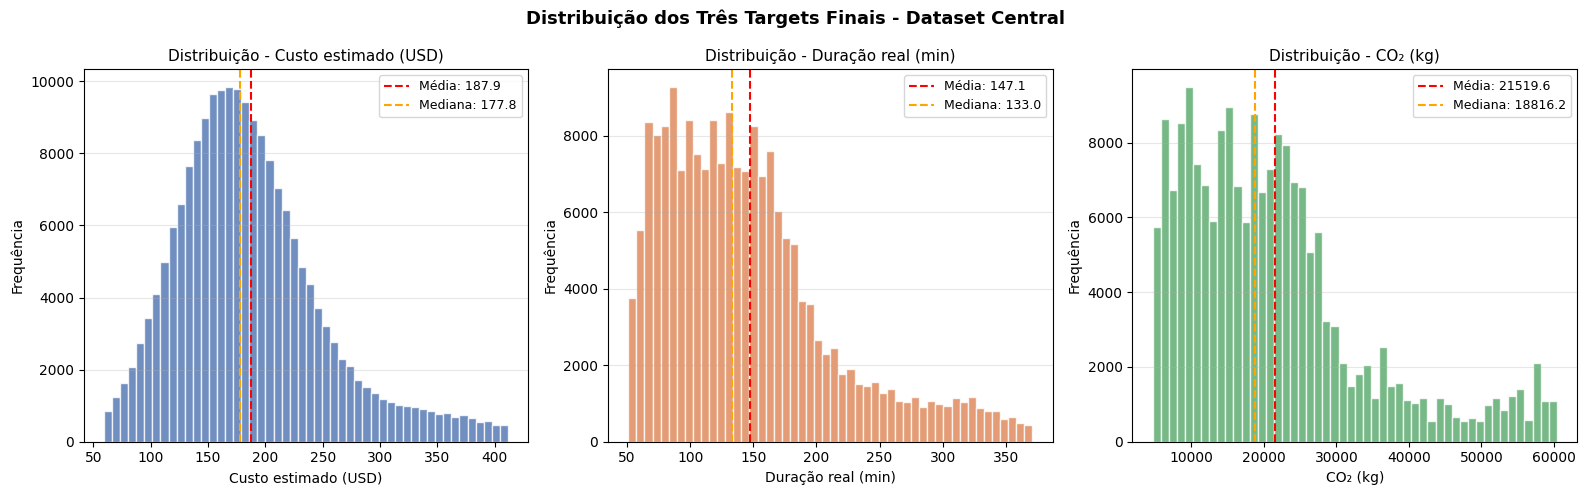

In [14]:
targets = [
    ('COST_PRED_USD',     'Custo estimado (USD)', 'LightGBM generalista'),
    ('DURATION_REAL_MIN', 'Duração real (min)',   'BTS observado/derivado'),
    ('CO2_kg',            'CO₂ (kg)',             'Fórmula ICAO'),
]

print('ESTATÍSTICAS DOS TARGETS FINAIS')
for col, label, origin in targets:
    if col in df_central.columns:
        s = df_central[col].describe()
        print(f'\n{label} [{origin}]')
        print(
            f'  mean={s["mean"]:.1f} | std={s["std"]:.1f} | '
            f'min={s["min"]:.1f} | median={s["50%"]:.1f} | max={s["max"]:.1f}'
        )
    else:
        print(f'\n{label}: coluna não encontrada no dataset central')

# Gráfico dos três targets finais usados na arquitetura:
# custo estimado, duração real e CO2 físico
plot_targets = [
    ('COST_PRED_USD',     'Custo estimado (USD)', 'LightGBM generalista'),
    ('DURATION_REAL_MIN', 'Duração real (min)',   'BTS observado/derivado'),
    ('CO2_kg',            'CO₂ (kg)',             'Fórmula ICAO'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, (col, label, _), color in zip(axes, plot_targets, colors):
    if col in df_central.columns:
        data = df_central[col].dropna()

        # Cortar extremos só para visualização, não altera o dataset
        p1, p99 = data.quantile(0.01), data.quantile(0.99)
        data_plot = data[(data >= p1) & (data <= p99)]

        ax.hist(data_plot, bins=50, color=color, alpha=0.8, edgecolor='white')
        ax.axvline(data.mean(), color='red', linestyle='--', label=f'Média: {data.mean():.1f}')
        ax.axvline(data.median(), color='orange', linestyle='--', label=f'Mediana: {data.median():.1f}')
        ax.set_xlabel(label)
        ax.set_ylabel('Frequência')
        ax.set_title(f'Distribuição - {label}', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.set_visible(False)

plt.suptitle('Distribuição dos Três Targets Finais - Dataset Central', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_targets_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

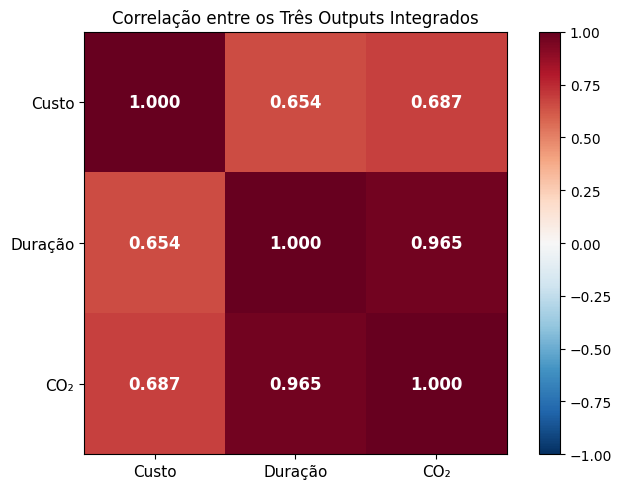

Correlação entre outputs integrados:
                   COST_PRED_USD  DURATION_REAL_MIN  CO2_kg
COST_PRED_USD              1.000              0.654   0.687
DURATION_REAL_MIN          0.654              1.000   0.965
CO2_kg                     0.687              0.965   1.000


In [15]:
# Correlação entre os três outputs integrados usados na arquitetura
target_cols = [c for c in ['COST_PRED_USD', 'DURATION_REAL_MIN', 'CO2_kg'] if c in df_central.columns]

labels = {
    'COST_PRED_USD': 'Custo',
    'DURATION_REAL_MIN': 'Duração',
    'CO2_kg': 'CO₂'
}

corr = df_central[target_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
lbl_list = [labels[c] for c in target_cols]
ax.set_xticks(range(len(target_cols))); ax.set_xticklabels(lbl_list, fontsize=11)
ax.set_yticks(range(len(target_cols))); ax.set_yticklabels(lbl_list, fontsize=11)
for i in range(len(target_cols)):
    for j in range(len(target_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.3f}', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if abs(corr.values[i,j]) > 0.5 else 'black')
ax.set_title('Correlação entre os Três Outputs Integrados', fontsize=12)
plt.tight_layout()
plt.savefig('fig_targets_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlação entre outputs integrados:')
print(corr.round(3).to_string())


## 8. Export

In [16]:
OUTPUT_PATH = 'generated_dataset.csv'
df_central.to_csv(OUTPUT_PATH, index=False)

print(f'Dataset central exportado: {OUTPUT_PATH}')
print(f'Shape: {df_central.shape}')
print()
print('Colunas exportadas:')
for i, col in enumerate(df_central.columns):
    nulls = df_central[col].isnull().sum()
    print(f'  {i+1:>2}. {col:<30} nulls={nulls}')

Dataset central exportado: generated_dataset.csv
Shape: (195950, 29)

Colunas exportadas:
   1. FL_DATE                        nulls=0
   2. AIRLINE_CODE                   nulls=0
   3. ORIGIN                         nulls=0
   4. DEST                           nulls=0
   5. ORIGIN_LAT                     nulls=0
   6. ORIGIN_LON                     nulls=0
   7. DEST_LAT                       nulls=0
   8. DEST_LON                       nulls=0
   9. haversine_distance             nulls=0
  10. route_nonlinearity             nulls=0
  11. Month                          nulls=0
  12. DayofWeek                      nulls=0
  13. DayofMonth                     nulls=0
  14. Quarter                        nulls=0
  15. IsWeekend                      nulls=0
  16. IsNightFlight                  nulls=0
  17. Season                         nulls=0
  18. CRS_DEP_TIME                   nulls=0
  19. DEP_HOUR                       nulls=0
  20. CRS_ELAPSED_TIME               nulls=0
  21. Roll

## 10. Resumo

In [17]:
print('RESUMO - Dataset Central (Fase 2)')
print(f'Registos: {len(df_central):,} voos domésticos EUA 2023')
print(f'Colunas:  {len(df_central.columns)}')
print()
print('CONSTRUÇÃO:')
print('  - Base: BTS 2023 dos notebooks de duração/atraso e emissões')
print('  - Custo: LightGBM generalista treinado a partir do sinal do RF do NB01')
print('    features: distância + companhia + mês + hora + dia da semana')
print('  - Duração: DURATION_REAL_MIN derivada dos dados BTS - fórmula: CRS_ELAPSED_TIME + ARR_DELAY - DEP_DELAY')
print('  - CO2: cálculo físico ICAO do NB03')
print()
print('CONTROLO DE LEAKAGE:')
print('  - Não exporta cost_per_km, co2_per_km, co2_per_pax_km')
print('  - Não exporta duration_error nem rolling_error_7d')
print('  - Não exporta CO2_PRED_kg como target alternativo')
print('  - Não inclui fuel_gallons_per_flight nesta versão base')
print()
print('OUTPUTS PRINCIPAIS:')
for col, label, origin in targets:
    if col in df_central.columns:
        print(f'  {col:<22} média={df_central[col].mean():.1f} | origem: {origin}')
print()
print(f'Output: {OUTPUT_PATH}')

RESUMO - Dataset Central (Fase 2)
Registos: 195,950 voos domésticos EUA 2023
Colunas:  29

CONSTRUÇÃO:
  - Base: BTS 2023 dos notebooks de duração/atraso e emissões
  - Custo: LightGBM generalista treinado a partir do sinal do RF do NB01
    features: distância + companhia + mês + hora + dia da semana
  - Duração: DURATION_REAL_MIN derivada dos dados BTS - fórmula: CRS_ELAPSED_TIME + ARR_DELAY - DEP_DELAY
  - CO2: cálculo físico ICAO do NB03

CONTROLO DE LEAKAGE:
  - Não exporta cost_per_km, co2_per_km, co2_per_pax_km
  - Não exporta duration_error nem rolling_error_7d
  - Não exporta CO2_PRED_kg como target alternativo
  - Não inclui fuel_gallons_per_flight nesta versão base

OUTPUTS PRINCIPAIS:
  COST_PRED_USD          média=187.9 | origem: LightGBM generalista
  DURATION_REAL_MIN      média=147.1 | origem: BTS observado/derivado
  CO2_kg                 média=21519.6 | origem: Fórmula ICAO

Output: generated_dataset.csv
